In [5]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output
from astropy.table import Table

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

In [6]:
catalog_path = "catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits"
catalog  = Table.read(catalog_path, format='fits')
catalog[:5]

INDEX,FIELD,CATALOG,ID,ID_V21,ID_V41,MASKNAME,SLITOBJNAME,RA,DEC,z,Z_QUAL,HA_FLUX,HA_FLUX_ERR,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_FWHM,HB_FWHM_ERR,HG_FLUX,HG_FLUX_ERR,HG_FWHM,HG_FWHM_ERR,HD_FLUX,HD_FLUX_ERR,HD_FWHM,HD_FWHM_ERR,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_FWHM,OII3730_FWHM_ERR,OIII4364_FLUX,OIII4364_FLUX_ERR,OIII4364_FWHM,OIII4364_FWHM_ERR,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_FWHM,OIII5008_FWHM_ERR,OI6302_FLUX,OI6302_FLUX_ERR,OI6302_FWHM,OI6302_FWHM_ERR,NII6550_FLUX,NII6550_FLUX_ERR,NII6550_FWHM,NII6550_FWHM_ERR,NII6585_FLUX,NII6585_FLUX_ERR,NII6585_FWHM,NII6585_FWHM_ERR,SII6718_FLUX,SII6718_FLUX_ERR,SII6718_FWHM,SII6718_FWHM_ERR,SII6733_FLUX,SII6733_FLUX_ERR,SII6733_FWHM,SII6733_FWHM_ERR,NEIII3870_FLUX,NEIII3870_FLUX_ERR,NEIII3870_FWHM,NEIII3870_FWHM_ERR,NEIII3969_FLUX,NEIII3969_FLUX_ERR,NEIII3969_FWHM,NEIII3969_FWHM_ERR,NIIHA,NIIHA_ERR,MASS_50,MASS_16,MASS_84,SFR_50,SFR_16,SFR_84,SSFR_50,SSFR_16,SSFR_84,AV_50,AV_16,AV_84,AGE_50,AGE_16,AGE_84,TAU_50,TAU_16,TAU_84,CHI2,ZFAST,EBV_STAR_16,EBV_STAR_50,EBV_STAR_84,HA_SN,HA_FLAG,HB_SN,HB_FLAG,HG_SN,HG_FLAG,HD_SN,HD_FLAG,OII3727_SN,OII3727_FLAG,OII3730_SN,OII3730_FLAG,OIII4364_SN,OIII4364_FLAG,OIII4960_SN,OIII4960_FLAG,OIII5008_SN,OIII5008_FLAG,OI6302_SN,OI6302_FLAG,NII6550_SN,NII6550_FLAG,NII6585_SN,NII6585_FLAG,SII6718_SN,SII6718_FLAG,SII6733_SN,SII6733_FLAG,NEIII3870_SN,NEIII3870_FLAG,NEIII3969_SN,NEIII3969_FLAG,O3,O3_ERR,O32,O32_ERR,EBV_NEB_16,EBV_NEB_50,EBV_NEB_84,FLUX_RADIUS,A_IMAGE,B_IMAGE,THETA_J2000,KRON_RADIUS,FWHM_IMAGE,CLASS_STAR,F_F160W,E_F160W,F_F814W,E_F814W,F_F606W,E_F606W,F_G,E_G,F_R,E_R,F_V,E_V,F_IRAC1,E_IRAC1,IRAC1_CONTAM,F_IRAC2,E_IRAC2,IRAC2_CONTAM,F_IRAC3,E_IRAC3,IRAC3_CONTAM,F_IRAC4,E_IRAC4,IRAC4_CONTAM,USE_PHOT,STAR_FLAG,PHOT_FLAGS,Z_SPEC,TOT_COR,SKELTON_MATCH,BA,INCL_DEG,GALFIT_FLAG_F160W,GALFIT_MAG_F160W,GALFIT_MAG_ERR_F160W,RE_F160W,RE_ERR_F160W,N_F160W,N_ERR_F160W,Q_F160W,Q_ERR_F160W,PA_F160W,PA_ERR_F160W,SN_F160W,VDW_MATCH_F160W,GALFIT_FLAG_F125W,GALFIT_MAG_F125W,GALFIT_MAG_ERR_F125W,RE_F125W,RE_ERR_F125W,N_F125W,N_ERR_F125W,Q_F125W,Q_ERR_F125W,PA_F125W,PA_ERR_F125W,SN_F125W,VDW_MATCH_F125W,RE_BEST,RE_BEST_SRC,Q_BEST,Q_BEST_SRC,RE_CIRC_BEST,MAG_G,MAG_R,MAG_V,MAG_F606W,MAG_F814W,MAG_F160W,GR_COLOR,Z_SECURE,Z_INWINDOW,BEST_LINE_SN,LINE_SN_OK,COORDS_OK,SAMPLE,HAS_DUP_0p5AS,DUP_DROP,BLEND_DROP,BLEND_MERGE,KEEP,XRAY_MATCH,XRAY_SEP_AS,XRAY_NAME,XRAY_FLUX_B,XRAY_SIG,AGN_XRAY,NIIHA_OK,BPT_O3HB,BPT_N2HA,AGN_OPT_USABLE,AGN_OPT,DONLEY_X,DONLEY_Y,AGN_IR_USABLE,AGN_IR,AGN_FLAG,CLEAN,MEX_O3HB,AGN_MEX,MEX_INTERMED,AGN_MEX_USABLE,AGN_MEX_APPLIED,VALID,EBV
int64,bytes6,bytes6,int64,int64,int64,bytes8,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

In [17]:
prod_egs_core    = core.read_core_fits("outputs_core/7-5-26-core_extraction_egs_MF.fits")
prod_cosmos_core = core.read_core_fits("outputs_core/7-5-26-core_extraction_cosmos_MF.fits")

prod_core = stack.concat_core_prods(prod_egs_core, prod_cosmos_core)
print(f"pooled {prod_core['n_per_input']} -> {len(prod_core['core_spec'])} galaxies")

pooled [244, 278] -> 522 galaxies


In [22]:
results_dict = prod_core['results']

# Find the row length from the first ndarray
n = next(len(v) for v in results_dict.values() if isinstance(v, np.ndarray))

results = Table({
    k: v
    for k, v in results_dict.items()
    if isinstance(v, np.ndarray) and len(v) == n
})

results[:5]

sn_mf,flux_mf,flux_mf_err,flux_b,flux_b_err,sn_b,flux_a,flux_a_err,mu,sigma,v_offset,v_offset_err,ew_rest,ew_rest_err,fesc,fesc_err,detected,label,gauss_success
float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,str8,bool
2.9511178,1.0672143,0.36163053,0.9335235,0.469327,1.9890684,1.6068827,0.53274965,1214.2662,2.387502,-346.16797,249.59976,2.78765,0.9446083,0.022891324,0.008210181,True,emitter,True
-1.8412267,-0.57223845,0.31079197,-0.7780591,0.3778672,-2.0590808,nan,nan,nan,nan,nan,nan,-1.0624771,0.57704854,nan,nan,False,absorber,False
12.101509,3.4000478,0.28096065,3.3619928,0.35986024,9.342496,3.6390083,0.25806144,1216.7267,0.95468134,260.59872,19.447996,3.669401,0.30321845,0.025829889,0.0035343645,True,emitter,True
5.352345,1.29431,0.24182111,1.8723875,0.3058491,6.1219325,2.004916,0.21931462,1217.0319,0.97282094,335.84222,30.823511,28.703993,5.3628817,0.03346175,0.01569534,True,LAE,True
4.3706203,1.4111422,0.32287002,1.2865876,0.37751436,3.4080493,1.7019448,0.36782485,1215.0531,1.7484484,-152.1337,75.274605,5.0120964,1.14677,0.013949041,0.009760684,True,emitter,True


/tmp/ipykernel_21742/4190513729.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_21742/4190513729.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_21742/4190513729.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(-50.0, 250.0)

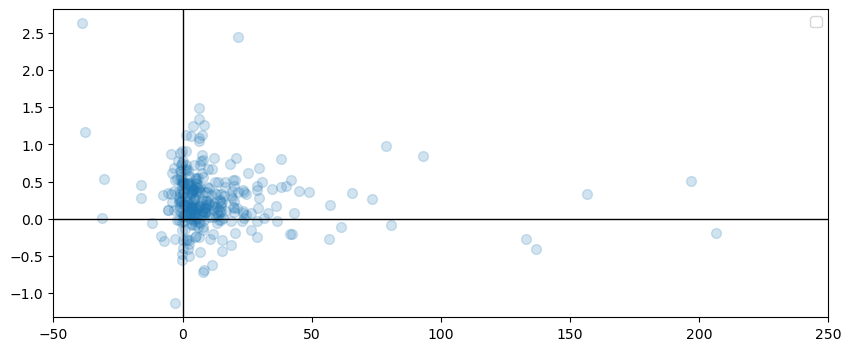

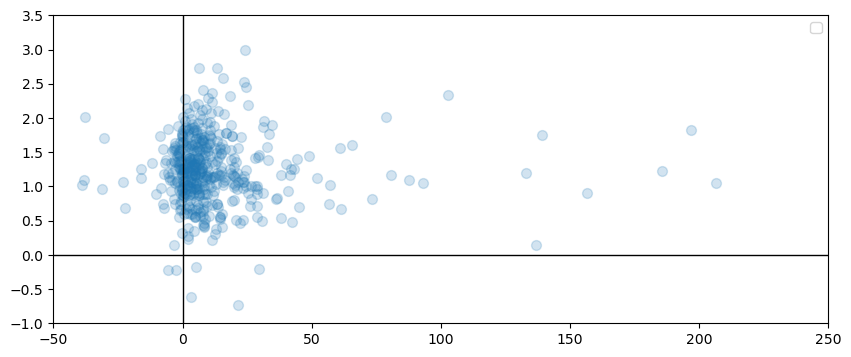

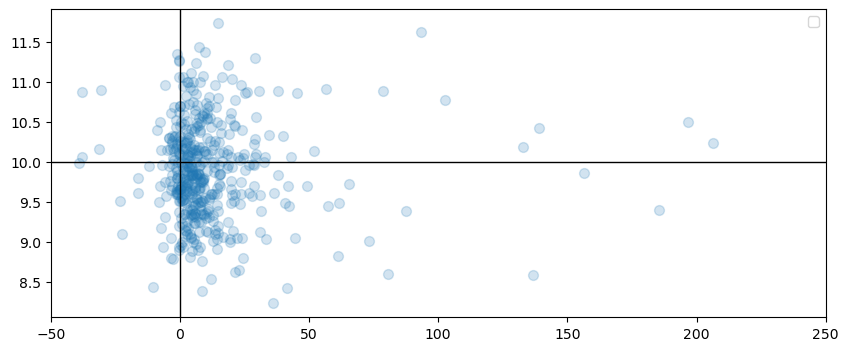

In [48]:
plt.figure(figsize=(10, 4))
plt.scatter(results['ew_rest'], catalog['EBV'], alpha=0.2, s=50)
plt.axvline(0, c='k', lw=1)
plt.axhline(0, c='k', lw=1)
plt.legend()
plt.xlim(-50, 250)

plt.figure(figsize=(10, 4))
plt.scatter(results['ew_rest'], catalog['SFR_50'], alpha=0.2, s=50)
plt.axvline(0, c='k', lw=1)
plt.axhline(0, c='k', lw=1)
plt.legend()
plt.xlim(-50, 250)
plt.ylim(-1, 3.5)

plt.figure(figsize=(10, 4))
plt.scatter(results['ew_rest'], catalog['MASS_50'], alpha=0.2, s=50)
plt.axvline(0, c='k', lw=1)
plt.axhline(10, c='k', lw=1)
plt.legend()
plt.xlim(-50, 250)